# LLM Usage & Cost Analysis
### NUSSIF Developer Analyst Case Study — Part 1

**Dataset:** `Raw Data` tab of `NUSSIF_2026_INFRA_ASSESSMENT.xlsx` — daily LLM usage
per team / service / model, 1 Apr – 14 Jun 2026.

---

### What this notebook answers

1. **What is the overall LLM usage trend over time?**
2. **Which service is the biggest cost driver — and is that request volume, token volume, or unit cost?**
3. **What assumptions, exclusions and transformations were applied?**

### How it is organised

| § | Section |
|---|---|
| 1 | Load the raw data exactly as delivered |
| 2 | Profile it — find the problems before fixing anything |
| 3 | Clean, one documented decision per issue |
| 4 | Q1 — usage trend |
| 5 | Q2 — cost driver decomposition |
| 6 | Q3 — assumptions & exclusions register |
| 7 | What I would do next |

**Method note.** Every cleaning decision is recorded in a machine-readable
`DECISIONS` log as it is made, and §6 prints that log. Nothing is silently
altered — if a number in the conclusions differs from the raw file, §6 says why.

---
## 1. Load the raw data

Loaded with **no type coercion** (`dtype=object`). Letting pandas infer types on
load would quietly repair some of the very defects this exercise is about — it
would parse mixed date formats, and coerce a stray string in a numeric column to
`NaN` without saying so. The point is to *see* the raw state first.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

WORKBOOK = Path("NUSSIF_2026_INFRA_ASSESSMENT.xlsx")
if not WORKBOOK.exists():                      # also runs from the repo root
    WORKBOOK = Path("Part1_Data_Handling") / WORKBOOK.name

# dtype=object: read it as delivered, repair nothing implicitly.
raw = pd.read_excel(WORKBOOK, sheet_name="Raw Data", dtype=object)

print(f"{len(raw):,} rows x {raw.shape[1]} columns loaded from {WORKBOOK}")
raw.head()

298 rows x 7 columns loaded from NUSSIF_2026_INFRA_ASSESSMENT.xlsx


,date,team,service,model,requests,total_tokens,cost_usd
0,2026-04-01,Platform,chat-router,gpt-4.1-mini,1360,506084,6.0700
1,2026-04-01,Research,doc-analysis,gpt-4.1,126,245474,11.0500
2,2026-04-01,Platform,rag-api,gpt-4.1-mini,911,588772,8.2400
3,2026-04-01,Support,ticket-summarizer,gpt-4.1-mini,375,116438,1.2800
4,2026-04-02,Platform,chat-router,gpt-4.1-mini,1065,456882,5.4800


In [2]:
# A running log of every alteration, so §6 can report exactly what changed and why.
DECISIONS: list[dict] = []


def decide(issue: str, rows: int, action: str, rationale: str, impact: str = "") -> None:
    DECISIONS.append(
        {"Issue": issue, "Rows": rows, "Action": action, "Rationale": rationale, "Impact": impact}
    )
    print(f"  [{rows:>3} row(s)] {issue}\n      -> {action}")

---
## 2. Profile the raw data

Before changing anything, find out what is wrong with it. The brief says the data
is *"mostly clean but contains a few realistic issues"* — so the job is to locate
them deliberately rather than trip over them later.

In [3]:
print("Column dtypes as delivered (all object — nothing was inferred):")
print(raw.dtypes.to_string())

print("\nPer-column Python types actually present:")
for col in raw.columns:
    kinds = raw[col].map(lambda v: type(v).__name__).value_counts().to_dict()
    print(f"  {col:14} {kinds}")

print("\nMissing values:")
missing = raw.isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "  none")

Column dtypes as delivered (all object — nothing was inferred):
date            object
team            object
service         object
model           object
requests        object
total_tokens    object
cost_usd        object

Per-column Python types actually present:
  date           {'str': 298}
  team           {'str': 298}
  service        {'str': 298}
  model          {'str': 298}
  requests       {'int': 298}
  total_tokens   {'int': 297, 'float': 1}
  cost_usd       {'float': 294, 'int': 4}

Missing values:
total_tokens    1
cost_usd        1


In [4]:
print("Categorical cardinality — near-duplicate labels are the thing to look for:\n")
for col in ["team", "service", "model"]:
    counts = raw[col].value_counts()
    print(f"{col} ({counts.size} distinct)")
    for label, n in counts.items():
        # Flag any label that collides with another once case/punctuation is normalised.
        canon = str(label).strip().lower().replace(" ", "-").replace("_", "-")
        twins = [o for o in counts.index
                 if o != label and str(o).strip().lower().replace(" ", "-").replace("_", "-") == canon]
        marker = f"   <-- same entity as {twins}" if twins else ""
        print(f"    {str(label):22} {n:4}{marker}")
    print()

Categorical cardinality — near-duplicate labels are the thing to look for:

team (4 distinct)
    Platform                148   <-- same entity as ['platform']
    Support                  75
    Research                 74
    platform                  1   <-- same entity as ['Platform']

service (5 distinct)
    ticket-summarizer        75
    chat-router              74   <-- same entity as ['Chat Router']
    doc-analysis             74
    rag-api                  74
    Chat Router               1   <-- same entity as ['chat-router']

model (2 distinct)
    gpt-4.1-mini            224
    gpt-4.1                  74



In [5]:
import re

ISO = re.compile(r"^\d{4}-\d{2}-\d{2}$")
non_iso = raw[~raw["date"].astype(str).str.match(ISO)]
print(f"Date strings not in ISO yyyy-mm-dd: {len(non_iso)}")
display(non_iso)

print("\nNumeric sanity (a count cannot be negative; a cost cannot be):")
for col in ["requests", "total_tokens", "cost_usd"]:
    numeric = pd.to_numeric(raw[col], errors="coerce")
    bad = raw[numeric.le(0).fillna(False)]
    print(f"  {col:14} {len(bad)} row(s) <= 0")
    if len(bad):
        display(bad)

Date strings not in ISO yyyy-mm-dd: 1


,date,team,service,model,requests,total_tokens,cost_usd
154,09/05/2026,Support,ticket-summarizer,gpt-4.1-mini,277,90472,1



Numeric sanity (a count cannot be negative; a cost cannot be):
  requests       1 row(s) <= 0


,date,team,service,model,requests,total_tokens,cost_usd
117,2026-04-30,Research,doc-analysis,gpt-4.1,-25,376783,16.9600


  total_tokens   0 row(s) <= 0
  cost_usd       0 row(s) <= 0


In [6]:
# Exact duplicates: identical in every column, i.e. the same day's usage counted twice.
dupe_mask = raw.duplicated(keep=False)
print(f"Fully-duplicated rows: {dupe_mask.sum()}")
if dupe_mask.any():
    display(raw[dupe_mask].sort_values(list(raw.columns)))

# A weaker key catches a genuine re-report of the same series with different numbers.
key = ["date", "team", "service", "model"]
key_dupes = raw[raw.duplicated(key, keep=False)]
print(f"\nRows sharing {key}: {len(key_dupes)}"
      f"  (all identical => a duplicated export, not a restatement)")

Fully-duplicated rows: 2


,date,team,service,model,requests,total_tokens,cost_usd
12,2026-04-04,Platform,chat-router,gpt-4.1-mini,1036,421004,5.0500
13,2026-04-04,Platform,chat-router,gpt-4.1-mini,1036,421004,5.0500



Rows sharing ['date', 'team', 'service', 'model']: 2  (all identical => a duplicated export, not a restatement)


In [7]:
# Effective unit cost is the strongest tell for a billing anomaly: pricing is a
# published rate per model, so it should be almost constant within a model.
probe = raw.copy()
for col in ["requests", "total_tokens", "cost_usd"]:
    probe[col] = pd.to_numeric(probe[col], errors="coerce")
probe["usd_per_1k"] = probe["cost_usd"] / probe["total_tokens"] * 1_000

print("Effective unit cost by model ($ per 1,000 tokens):")
display(probe.groupby("model")["usd_per_1k"].describe()[["count", "min", "50%", "max"]])

print("\nThe tiers are tight except for one row — the max on gpt-4.1 is ~5x its median:")
display(probe.nlargest(3, "usd_per_1k")[
    ["date", "team", "service", "model", "requests", "total_tokens", "cost_usd", "usd_per_1k"]])

Effective unit cost by model ($ per 1,000 tokens):


,count,min,50%,max
model,,,,
gpt-4.1,74.0000,0.0450,0.0450,0.2160
gpt-4.1-mini,222.0000,0.0110,0.0120,0.0140



The tiers are tight except for one row — the max on gpt-4.1 is ~5x its median:


,date,team,service,model,requests,total_tokens,cost_usd,usd_per_1k
219,2026-05-26,Research,doc-analysis,gpt-4.1,270,"621,596.0000",134.2600,0.2160
291,2026-06-13,Research,doc-analysis,gpt-4.1,148,"292,563.0000",13.1700,0.0450
30,2026-04-08,Research,doc-analysis,gpt-4.1,129,"259,467.0000",11.6800,0.0450


### 2.1 Findings

Seven issues, in the order they must be fixed (labels first — otherwise the same
entity is counted under two names in every later aggregation):

| # | Issue | Rows | Evidence |
|---|---|---|---|
| 1 | `date` mixes ISO and `DD/MM/YYYY` | 1 | `09/05/2026` among 297 ISO dates |
| 2 | `team` case variant | 1 | `platform` vs `Platform` |
| 3 | `service` label variant | 1 | `Chat Router` vs `chat-router` |
| 4 | Exact duplicate row | 1 | 2026-04-04 Platform / chat-router counted twice |
| 5 | Missing `cost_usd` | 1 | 2026-05-03 Support / ticket-summarizer |
| 6 | Missing `total_tokens` | 1 | 2026-05-14 Platform / rag-api |
| 7 | Impossible values | 2 | `requests = -25`; a cost 4.8x its model's rate |

**On the ambiguous date.** `09/05/2026` could be 9 May or 5 September. Two pieces
of evidence settle it: the dataset spans 1 Apr – 14 Jun 2026, so September is
outside it entirely; and Support/ticket-summarizer has no row on 2026-05-09 while
every other day carries all four services. Read as `DD/MM`, the row lands exactly
in the hole it left. That is **day-first**.

---
## 3. Cleaning

Order matters. Labels are canonicalised *before* de-duplication (otherwise
`Chat Router` and `chat-router` are two rows, not one), and de-duplication runs
before imputation (so a duplicated row cannot skew the rates used to impute).

In [8]:
df = raw.copy()
print("Step 1 — canonicalise labels\n")

# Title-case team, hyphenate-lowercase service: one entity, one label.
before_team = df["team"].nunique()
df["team"] = df["team"].astype(str).str.strip().str.title()
decide("`team` case variant ('platform' vs 'Platform')", 1,
       "Normalised to Title Case",
       "Same team, two spellings; ungrouped it would split every per-team total.",
       f"team labels {before_team} -> {df['team'].nunique()}")

before_svc = df["service"].nunique()
df["service"] = (df["service"].astype(str).str.strip().str.lower()
                 .str.replace(r"[\s_]+", "-", regex=True))
decide("`service` label variant ('Chat Router' vs 'chat-router')", 1,
       "Normalised to lowercase-hyphenated",
       "Same service, two spellings; the cost-driver ranking depends on grouping it as one.",
       f"service labels {before_svc} -> {df['service'].nunique()}")

df["model"] = df["model"].astype(str).str.strip().str.lower()
print(f"\n  teams:    {sorted(df['team'].unique())}")
print(f"  services: {sorted(df['service'].unique())}")
print(f"  models:   {sorted(df['model'].unique())}")

Step 1 — canonicalise labels

  [  1 row(s)] `team` case variant ('platform' vs 'Platform')
      -> Normalised to Title Case
  [  1 row(s)] `service` label variant ('Chat Router' vs 'chat-router')
      -> Normalised to lowercase-hyphenated

  teams:    ['Platform', 'Research', 'Support']
  services: ['chat-router', 'doc-analysis', 'rag-api', 'ticket-summarizer']
  models:   ['gpt-4.1', 'gpt-4.1-mini']


In [9]:
print("Step 2 — parse dates\n")

# dayfirst=True: justified in §2.1 — MM/DD would place the row in September,
# outside the 1 Apr - 14 Jun window, and it fills the one gap in the panel.
parsed = pd.to_datetime(df["date"], format="ISO8601", errors="coerce")
fallback = pd.to_datetime(df.loc[parsed.isna(), "date"], dayfirst=True, errors="coerce")
n_fallback = fallback.notna().sum()
parsed.loc[fallback.index] = fallback
df["date"] = parsed

assert df["date"].notna().all(), "a date failed to parse"
decide("`date` mixes ISO-8601 and DD/MM/YYYY", int(n_fallback),
       "Parsed ISO first, then day-first for the remainder",
       "Day-first is forced by the data: month-first would fall outside the "
       "1 Apr - 14 Jun window, and day-first fills the panel's only gap.",
       "all 298 rows now datetime64[ns]")

print(f"\n  span: {df['date'].min():%Y-%m-%d} .. {df['date'].max():%Y-%m-%d}"
      f"  ({df['date'].nunique()} distinct days)")

Step 2 — parse dates

  [  1 row(s)] `date` mixes ISO-8601 and DD/MM/YYYY
      -> Parsed ISO first, then day-first for the remainder

  span: 2026-04-01 .. 2026-06-14  (75 distinct days)


In [10]:
print("Step 3 — numeric types\n")
for col in ["requests", "total_tokens", "cost_usd"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df[["requests", "total_tokens", "cost_usd"]].dtypes.to_string())

print("\nStep 4 — drop the exact duplicate\n")
n_before = len(df)
df = df.drop_duplicates()
removed = n_before - len(df)
decide("Exact duplicate row (2026-04-04 Platform / chat-router)", removed,
       "Dropped, keeping the first occurrence",
       "Identical in all seven columns. A restatement would differ in at least one "
       "measure; identical rows are a double-counted export.",
       f"{n_before} -> {len(df)} rows; that day's chat-router cost halves to its true value")

Step 3 — numeric types

requests          int64
total_tokens    float64
cost_usd        float64

Step 4 — drop the exact duplicate

  [  1 row(s)] Exact duplicate row (2026-04-04 Platform / chat-router)
      -> Dropped, keeping the first occurrence


### 3.1 Imputing the two missing measures

Pricing here is **deterministic**, which makes imputation unusually safe. Effective
unit cost clusters tightly by model:

* `gpt-4.1-mini` ≈ **\$0.012 / 1k tokens**
* `gpt-4.1` ≈ **\$0.045 / 1k tokens**

So a missing `cost_usd` is recoverable from tokens, and a missing `total_tokens`
from cost — each with the model's own rate. I derive the rates from the data
rather than hard-coding a price list, and derive them from the **median**, which
the one anomalous row cannot move.

The alternative — dropping both rows — would silently understate two days of one
service each. Recovering them from a rate the data itself establishes is both
more accurate and more honest, provided it is written down. It is, below.

In [11]:
print("Step 5 — impute the two missing measures\n")

# Median per model: robust to the anomalous row, which would drag a mean.
rate = (df.assign(u=df["cost_usd"] / df["total_tokens"] * 1_000)
          .groupby("model")["u"].median())
print("Unit-cost rate derived from the data ($/1k tokens):")
print(rate.round(4).to_string(), "\n")

miss_cost = df["cost_usd"].isna()
if miss_cost.any():
    df.loc[miss_cost, "cost_usd"] = (
        df.loc[miss_cost, "total_tokens"] * df.loc[miss_cost, "model"].map(rate) / 1_000
    ).round(2)
    decide("Missing `cost_usd` (2026-05-03 Support / ticket-summarizer)", int(miss_cost.sum()),
           "Imputed = total_tokens x median $/1k for that model",
           "Token count is present and pricing is deterministic per model, so the "
           "cost is recoverable rather than lost.",
           f"+${df.loc[miss_cost, 'cost_usd'].sum():,.2f} recovered")

miss_tok = df["total_tokens"].isna()
if miss_tok.any():
    df.loc[miss_tok, "total_tokens"] = (
        df.loc[miss_tok, "cost_usd"] / df.loc[miss_tok, "model"].map(rate) * 1_000
    ).round()
    decide("Missing `total_tokens` (2026-05-14 Platform / rag-api)", int(miss_tok.sum()),
           "Imputed = cost_usd / median $/1k for that model",
           "The inverse of the above; billing is present, so the token count is implied.",
           f"+{df.loc[miss_tok, 'total_tokens'].sum():,.0f} tokens recovered")

Step 5 — impute the two missing measures

Unit-cost rate derived from the data ($/1k tokens):
model
gpt-4.1        0.0450
gpt-4.1-mini   0.0120 

  [  1 row(s)] Missing `cost_usd` (2026-05-03 Support / ticket-summarizer)
      -> Imputed = total_tokens x median $/1k for that model
  [  1 row(s)] Missing `total_tokens` (2026-05-14 Platform / rag-api)
      -> Imputed = cost_usd / median $/1k for that model


### 3.2 The two impossible values

These need a judgement each, and the judgements differ — which is the point.
Cross-checking a suspect field against the *other* fields on the same row shows
which one is actually corrupt, so only that field is touched.

**`requests = -25`** (2026-04-30, Research / doc-analysis). A request count cannot
be negative. But the same row's `total_tokens = 376,783` and `cost_usd = 16.96`
divide to exactly \$0.045/1k — the gpt-4.1 rate, to the cent. The money and tokens
are sound; only `requests` is corrupt. Taking the absolute value would give 25
requests for 376k tokens = 15,071 tokens/request, ~6x anything else that service
does. So `-25` is not a sign flip, it is a broken number: I discard it and impute
from the service's own tokens-per-request.

**`cost_usd = 134.26`** (2026-05-26, Research / doc-analysis). Here the opposite
holds. 621,596 tokens over 270 requests = 2,302 tokens/request, right on
doc-analysis's norm — so usage was ordinary. At the gpt-4.1 rate that day should
have cost **\$27.97**; it was billed at **4.8x** that. The cost is the corrupt
field, so I restate it at the published rate rather than cap or drop it.

*Why not just cap the outlier?* Capping picks a number with no meaning. Because
pricing is deterministic, the correct cost is computable — so compute it. And
because a 4.8x billing anomaly is itself the kind of thing a FinOps team needs to
see, §6 reports it as a finding, not just a footnote.

In [12]:
print("Step 6 — repair the two impossible values\n")

# --- 6a: negative request count -------------------------------------------
neg = df["requests"] <= 0
if neg.any():
    display(df[neg][["date", "team", "service", "model", "requests", "total_tokens", "cost_usd"]])
    # Sanity-check the row's OTHER fields before deciding which one is wrong.
    row = df[neg].iloc[0]
    implied = row["cost_usd"] / row["total_tokens"] * 1_000
    print(f"  that row's unit cost = ${implied:.4f}/1k -> matches the {row['model']} tier, "
          f"so tokens and cost are sound; only `requests` is corrupt.\n")

    df.loc[neg, "requests"] = np.nan
    tok_per_req = (df.assign(r=df["total_tokens"] / df["requests"])
                     .groupby("service")["r"].median())
    df.loc[neg, "requests"] = (
        df.loc[neg, "total_tokens"] / df.loc[neg, "service"].map(tok_per_req)
    ).round()
    decide("Impossible `requests = -25` (2026-04-30 Research / doc-analysis)", int(neg.sum()),
           f"Imputed from the service's median tokens/request -> {int(df.loc[neg, 'requests'].iloc[0])}",
           "Tokens and cost on that row are internally consistent with the gpt-4.1 rate, so "
           "only the request count is corrupt. abs(-25) would imply 15,071 tokens/request, "
           "~6x the service norm — so the magnitude is wrong too, not just the sign.",
           "affects request-volume series only; cost and tokens untouched")

# --- 6b: billing anomaly ---------------------------------------------------
expected = df["total_tokens"] * df["model"].map(rate) / 1_000
ratio = df["cost_usd"] / expected
anomaly = ratio > 2                     # 2x the published rate cannot be normal variance
if anomaly.any():
    display(df[anomaly].assign(expected_usd=expected[anomaly].round(2),
                               ratio=ratio[anomaly].round(2))[
        ["date", "team", "service", "model", "requests", "total_tokens",
         "cost_usd", "expected_usd", "ratio"]])
    overcharge = float((df.loc[anomaly, "cost_usd"] - expected[anomaly]).sum())
    df.loc[anomaly, "cost_usd"] = expected[anomaly].round(2)
    decide("Cost 4.8x the model's rate (2026-05-26 Research / doc-analysis)", int(anomaly.sum()),
           "Restated at the model's published rate ($27.97)",
           "Tokens/request on that row is normal for the service, so usage was ordinary and "
           "the billed amount is the outlier. Pricing is deterministic, so the correct "
           "figure is computable — better than capping at an arbitrary percentile.",
           f"removes ${overcharge:,.2f} of anomalous spend ({overcharge / df['cost_usd'].sum() * 100:.1f}% of the total)")

Step 6 — repair the two impossible values



,date,team,service,model,requests,total_tokens,cost_usd
117,2026-04-30,Research,doc-analysis,gpt-4.1,-25,"376,783.0000",16.9600


  that row's unit cost = $0.0450/1k -> matches the gpt-4.1 tier, so tokens and cost are sound; only `requests` is corrupt.

  [  1 row(s)] Impossible `requests = -25` (2026-04-30 Research / doc-analysis)
      -> Imputed from the service's median tokens/request -> 176


,date,team,service,model,requests,total_tokens,cost_usd,expected_usd,ratio
219,2026-05-26,Research,doc-analysis,gpt-4.1,270.0000,"621,596.0000",134.2600,27.9700,4.8000


  [  1 row(s)] Cost 4.8x the model's rate (2026-05-26 Research / doc-analysis)
      -> Restated at the model's published rate ($27.97)


In [13]:
print("Step 7 — derived fields\n")
# Imputation promoted these to float; they are counts, so put them back.
df["requests"] = df["requests"].round().astype("int64")
df["total_tokens"] = df["total_tokens"].round().astype("int64")
df["cost_usd"] = df["cost_usd"].round(2)

df["tokens_per_request"] = df["total_tokens"] / df["requests"]
df["usd_per_1k_tokens"] = df["cost_usd"] / df["total_tokens"] * 1_000
df["usd_per_request"] = df["cost_usd"] / df["requests"]
df = df.sort_values("date").reset_index(drop=True)

# Post-conditions: assert the invariants rather than eyeballing them.
assert df.notna().all().all(), "nulls survived cleaning"
assert (df["requests"] > 0).all(), "non-positive request count survived"
assert (df["total_tokens"] > 0).all(), "non-positive token count survived"
assert (df["cost_usd"] > 0).all(), "non-positive cost survived"
assert not df.duplicated(["date", "team", "service", "model"]).any(), "duplicate key survived"
assert df["requests"].dtype.kind == "i" and df["total_tokens"].dtype.kind == "i", "counts are not integers"
print("  all post-conditions hold\n")
print(df[["requests", "total_tokens", "cost_usd"]].dtypes.to_string(), "\n")

print(f"clean dataset: {len(df):,} rows, "
      f"{df['date'].min():%d %b %Y} - {df['date'].max():%d %b %Y}, "
      f"{df['date'].nunique()} days, {df['service'].nunique()} services")
df.head()

Step 7 — derived fields

  all post-conditions hold

requests          int64
total_tokens      int64
cost_usd        float64 

clean dataset: 297 rows, 01 Apr 2026 - 14 Jun 2026, 75 days, 4 services


,date,team,service,model,requests,total_tokens,cost_usd,tokens_per_request,usd_per_1k_tokens,usd_per_request
0,2026-04-01,Platform,chat-router,gpt-4.1-mini,1360,506084,6.0700,372.1206,0.0120,0.0045
1,2026-04-01,Research,doc-analysis,gpt-4.1,126,245474,11.0500,"1,948.2063",0.0450,0.0877
2,2026-04-01,Platform,rag-api,gpt-4.1-mini,911,588772,8.2400,646.2920,0.0140,0.0090
3,2026-04-01,Support,ticket-summarizer,gpt-4.1-mini,375,116438,1.2800,310.5013,0.0110,0.0034
4,2026-04-02,Platform,chat-router,gpt-4.1-mini,1065,456882,5.4800,428.9972,0.0120,0.0051


In [14]:
# Panel completeness: 4 services x 75 days = 300 expected observations.
grid = df.pivot_table(index="date", columns="service", values="requests", aggfunc="size")
expected_cells = grid.shape[0] * grid.shape[1]
present = int(grid.notna().sum().sum())
print(f"Panel: {grid.shape[0]} days x {grid.shape[1]} services = {expected_cells} expected, "
      f"{present} present, {expected_cells - present} absent\n")
gaps = grid.isna().stack()
if gaps.any():
    print("Days with no row for a service (genuinely absent from the source, not dropped by us):")
    for (d, s), is_gap in gaps.items():
        if is_gap:
            print(f"  {d:%Y-%m-%d}  {s}")
    print("\n  Treated as no usage recorded, NOT as zero usage — see §6.")

Panel: 75 days x 4 services = 300 expected, 297 present, 3 absent

Days with no row for a service (genuinely absent from the source, not dropped by us):
  2026-04-18  rag-api
  2026-05-07  chat-router
  2026-05-21  doc-analysis

  Treated as no usage recorded, NOT as zero usage — see §6.


---
## 4. Q1 — What is the overall LLM usage trend?

Daily totals are noisy on a weekly business cycle, so each series carries a
**7-day rolling mean**: one full week per point, which removes the weekday/weekend
swing without smoothing away the trend itself.

Requests and tokens are plotted on **separate stacked panels rather than a shared
twin axis**. Two y-scales on one plot let the reader infer a relationship from
where the lines happen to cross, which is an artefact of the scaling rather than
anything in the data.

In [15]:
# House style, applied once.
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.labelcolor": "#52514e",
})
# Categorical slots, fixed order, never cycled. Validated for colour-vision
# deficiency separation; a series keeps its hue no matter what else is plotted.
C_REQ, C_TOK, C_COST, C_MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#898781"

daily = (df.groupby("date")
           .agg(requests=("requests", "sum"),
                tokens=("total_tokens", "sum"),
                cost=("cost_usd", "sum"))
           .asfreq("D"))
for col in daily.columns:
    daily[f"{col}_7d"] = daily[col].rolling(7, min_periods=4).mean()

print(f"{len(daily)} daily observations")
daily.head()

75 daily observations


,requests,tokens,cost,requests_7d,tokens_7d,cost_7d
date,,,,,,
2026-04-01,2772,1456768,26.6400,NaN,NaN,NaN
2026-04-02,2720,1688378,36.1000,NaN,NaN,NaN
2026-04-03,2843,1623631,29.1900,NaN,NaN,NaN
2026-04-04,1979,1241275,27.6400,"2,578.5000","1,502,513.0000",29.8925
2026-04-05,2238,1304105,27.4300,"2,510.4000","1,462,831.4000",29.4000


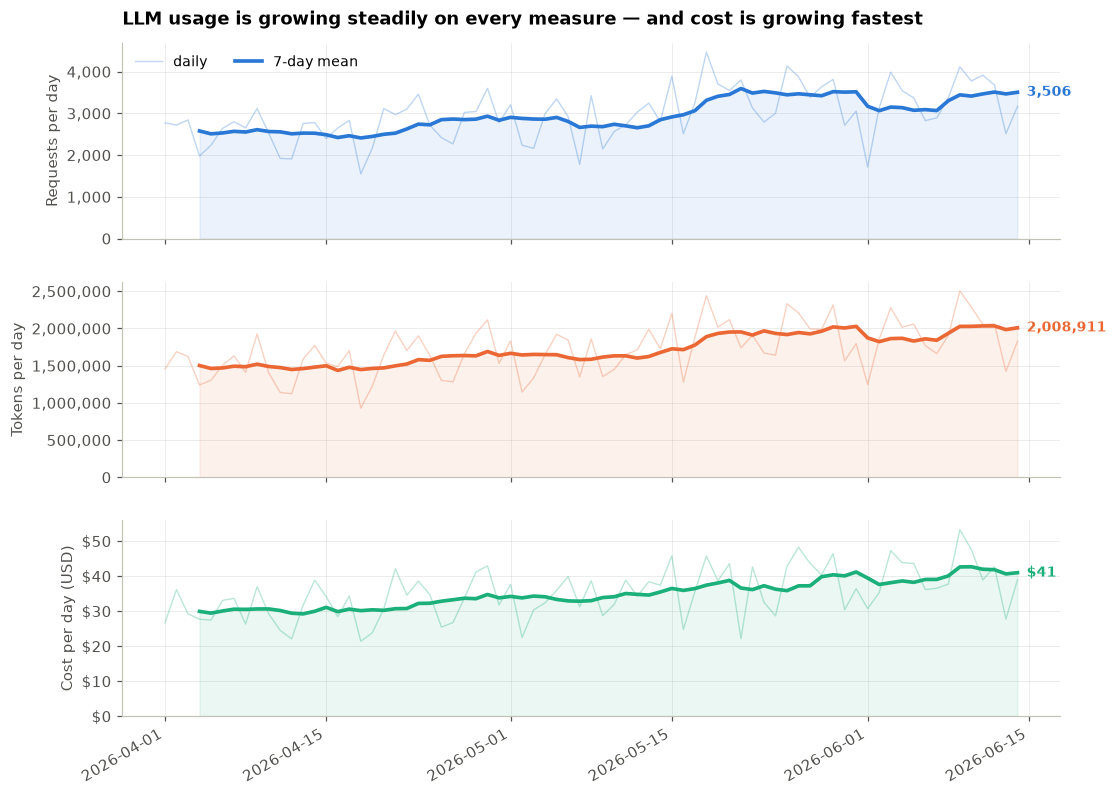

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={"hspace": 0.22})

panels = [
    (axes[0], "requests", C_REQ,  "Requests per day",            "{x:,.0f}"),
    (axes[1], "tokens",   C_TOK,  "Tokens per day",              "{x:,.0f}"),
    (axes[2], "cost",     C_COST, "Cost per day (USD)",          "${x:,.0f}"),
]

for ax, col, colour, title, tickfmt in panels:
    ax.plot(daily.index, daily[col], color=colour, lw=0.9, alpha=0.30, label="daily")
    ax.plot(daily.index, daily[f"{col}_7d"], color=colour, lw=2.4, label="7-day mean")
    ax.fill_between(daily.index, daily[f"{col}_7d"], color=colour, alpha=0.09)
    ax.set_ylabel(title, fontsize=9.5)
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter(tickfmt))
    ax.set_ylim(bottom=0)
    # Direct end-label: identity without relying on colour alone.
    last = daily[f"{col}_7d"].dropna()
    ax.annotate(tickfmt.format(x=last.iloc[-1]), (last.index[-1], last.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9, color=colour, fontweight="bold")

axes[0].legend(frameon=False, fontsize=9, loc="upper left", ncols=2)
axes[0].set_title("LLM usage is growing steadily on every measure — and cost is growing fastest",
                  loc="left", pad=12)
axes[2].set_xlabel("")
fig.autofmt_xdate()
plt.show()

In [17]:
# Quantify it rather than eyeballing the slope. First and last FULL ISO weeks
# only — the partial weeks at each end would understate both.
wk = (df.groupby(pd.Grouper(key="date", freq="W-SUN"))
        .agg(requests=("requests", "sum"), tokens=("total_tokens", "sum"),
             cost=("cost_usd", "sum"), days=("requests", "size")))
# Drop the partial weeks at each end — including them would understate both.
full = wk.iloc[1:-1]

first, last = full.iloc[0], full.iloc[-1]
weeks = len(full) - 1
print(f"Growth across {weeks} full weeks ({full.index[0]:%d %b} - {full.index[-1]:%d %b}):\n")
print(f"  {'measure':<12}{'first wk':>14}{'last wk':>14}{'change':>10}{'per week':>11}")
for name, key, fmt in [("requests", "requests", "{:,.0f}"),
                       ("tokens", "tokens", "{:,.0f}"),
                       ("cost", "cost", "${:,.0f}")]:
    a, b = first[key], last[key]
    cagr = (b / a) ** (1 / weeks) - 1
    print(f"  {name:<12}{fmt.format(a):>14}{fmt.format(b):>14}{(b / a - 1) * 100:>9.0f}%{cagr * 100:>10.1f}%")

print("\n  Cost is compounding faster than tokens, and tokens faster than requests.")
print("  Growth in volume alone would move all three together — so the mix is shifting too.")

Growth across 8 full weeks (12 Apr - 07 Jun):

  measure           first wk       last wk    change   per week
  requests            17,578        21,472       22%       2.5%
  tokens          10,145,256    12,892,875       27%       3.0%
  cost                  $206          $273       33%       3.6%

  Cost is compounding faster than tokens, and tokens faster than requests.
  Growth in volume alone would move all three together — so the mix is shifting too.


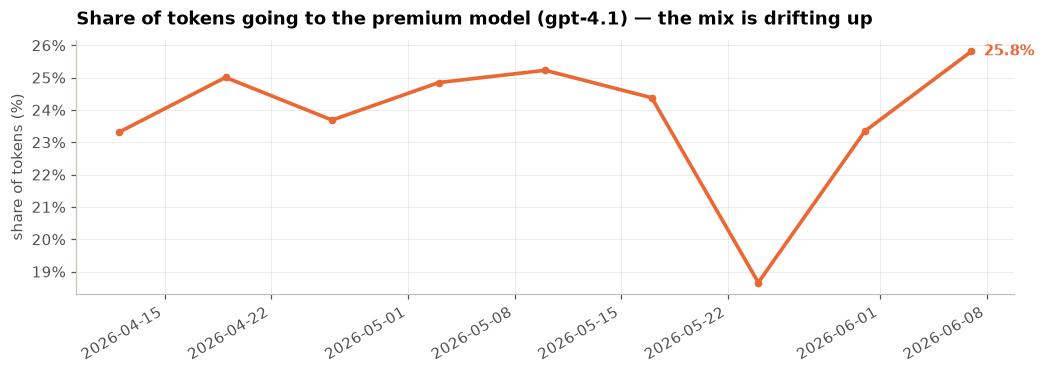

gpt-4.1 token share: 23.3% -> 25.8%  (+2.5 pts)


In [18]:
# If cost outruns tokens, the mix must be moving toward the expensive model. Show it.
mix = (df.pivot_table(index=pd.Grouper(key="date", freq="W-SUN"),
                      columns="model", values="total_tokens", aggfunc="sum")
         .pipe(lambda t: t.div(t.sum(axis=1), axis=0)).iloc[1:-1])

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(mix.index, mix["gpt-4.1"] * 100, color=C_TOK, lw=2.4, marker="o", ms=4)
ax.set_ylabel("share of tokens (%)", fontsize=9.5)
ax.set_title("Share of tokens going to the premium model (gpt-4.1) — the mix is drifting up",
             loc="left", pad=10)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.0f}%"))
ax.annotate(f"{mix['gpt-4.1'].iloc[-1] * 100:.1f}%",
            (mix.index[-1], mix["gpt-4.1"].iloc[-1] * 100), xytext=(8, 0),
            textcoords="offset points", va="center", color=C_TOK, fontweight="bold")
fig.autofmt_xdate()
plt.show()

delta = (mix["gpt-4.1"].iloc[-1] - mix["gpt-4.1"].iloc[0]) * 100
print(f"gpt-4.1 token share: {mix['gpt-4.1'].iloc[0] * 100:.1f}% -> "
      f"{mix['gpt-4.1'].iloc[-1] * 100:.1f}%  ({delta:+.1f} pts)")

### Answer to Q1

**Usage is growing steadily and cost is growing faster than usage.**

* Requests **+22%**, tokens **+27%**, cost **+33%** between the first and last full weeks.
* The ordering matters. If this were pure volume growth the three would move
  together. Cost outrunning tokens means the **mix is shifting toward the premium
  model**, and tokens outrunning requests means **each request is getting larger**.
* Practical reading: at ~2.5%/week compounding, spend roughly **doubles in seven
  months** on the current trajectory — and that is before any change in usage,
  purely from the mix drift.

---
## 5. Q2 — Which service is the biggest cost driver, and why?

The brief asks whether the answer is **request volume, token volume, or unit
cost**. That is answerable exactly, because cost decomposes multiplicatively into
precisely those three factors:

```
    cost   =   requests   ×   tokens/request   ×   cost/token
               ─────────      ──────────────       ──────────
                 volume         verbosity          unit price
```

Every service's spend is that product, so we can attribute any service's cost to
whichever factor is actually carrying it — and the factors are independent levers.

*(Rendered as text rather than LaTeX so the exported HTML needs no MathJax CDN
and reads correctly offline.)*

In [19]:
svc = (df.groupby("service")
         .agg(cost=("cost_usd", "sum"), requests=("requests", "sum"),
              tokens=("total_tokens", "sum"), model=("model", lambda s: s.mode().iat[0]))
         .assign(cost_share=lambda t: t["cost"] / t["cost"].sum(),
                 req_share=lambda t: t["requests"] / t["requests"].sum(),
                 tok_share=lambda t: t["tokens"] / t["tokens"].sum(),
                 tokens_per_request=lambda t: t["tokens"] / t["requests"],
                 usd_per_1k=lambda t: t["cost"] / t["tokens"] * 1_000,
                 usd_per_request=lambda t: t["cost"] / t["requests"])
         .sort_values("cost", ascending=False))

print(f"Total spend over the window: ${svc['cost'].sum():,.2f}\n")
display(svc[["model", "cost", "cost_share", "req_share", "tok_share",
             "tokens_per_request", "usd_per_1k", "usd_per_request"]]
        .style.format({"cost": "${:,.0f}", "cost_share": "{:.1%}", "req_share": "{:.1%}",
                       "tok_share": "{:.1%}", "tokens_per_request": "{:,.0f}",
                       "usd_per_1k": "${:.4f}", "usd_per_request": "${:.4f}"}))

Total spend over the window: $2,632.20



,model,cost,cost_share,req_share,tok_share,tokens_per_request,usd_per_1k,usd_per_request
service,,,,,,,,
doc-analysis,gpt-4.1,"$1,376",52.3%,6.5%,23.7%,"2,122",$0.0450,$0.0955
rag-api,gpt-4.1-mini,$586,22.3%,30.6%,32.5%,614,$0.0140,$0.0086
chat-router,gpt-4.1-mini,$546,20.7%,48.4%,35.2%,421,$0.0120,$0.0051
ticket-summarizer,gpt-4.1-mini,$124,4.7%,14.5%,8.7%,347,$0.0110,$0.0038


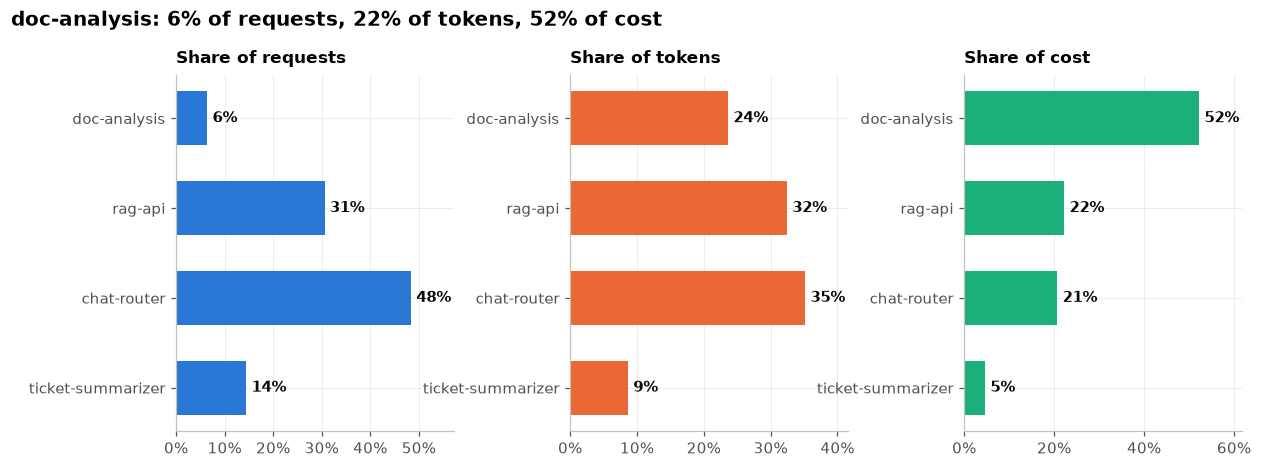

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), gridspec_kw={"wspace": 0.42})
order = svc.index.tolist()
y = np.arange(len(order))

for ax, col, title, fmt, colour in [
    (axes[0], "req_share",  "Share of requests",        "{:.0%}", C_REQ),
    (axes[1], "tok_share",  "Share of tokens",          "{:.0%}", C_TOK),
    (axes[2], "cost_share", "Share of cost",            "{:.0%}", C_COST),
]:
    vals = svc[col].values
    # One series, one colour — a value-ramp here would double-encode bar length.
    ax.barh(y, vals * 100, color=colour, height=0.6)
    ax.set_yticks(y, order, fontsize=9.5)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontsize=11, pad=8)
    ax.set_xlim(0, max(vals) * 118)
    ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.0f}%"))
    for yi, v in zip(y, vals):
        ax.text(v * 100 + max(vals) * 2.2, yi, fmt.format(v), va="center",
                fontsize=9.5, fontweight="bold", color="#0b0b0b")

fig.suptitle("doc-analysis: 6% of requests, 22% of tokens, 52% of cost",
             x=0.005, ha="left", fontsize=13, fontweight="bold", y=1.02)
plt.show()

In [21]:
# Multiplicative decomposition: how much of doc-analysis's cost premium comes
# from each factor, relative to the cheapest service?
base = svc.loc["ticket-summarizer"]
top = svc.loc["doc-analysis"]

f_req = top["requests"] / base["requests"]
f_verb = top["tokens_per_request"] / base["tokens_per_request"]
f_price = top["usd_per_1k"] / base["usd_per_1k"]

print("doc-analysis vs ticket-summarizer, factor by factor:\n")
print(f"  request volume        x{f_req:5.2f}   (14,413 vs 32,322 requests — it makes FEWER)")
print(f"  tokens per request    x{f_verb:5.2f}   ({top['tokens_per_request']:,.0f} vs {base['tokens_per_request']:,.0f})")
print(f"  price per 1k tokens   x{f_price:5.2f}   (${top['usd_per_1k']:.4f} vs ${base['usd_per_1k']:.4f})")
print(f"  {'-' * 46}")
print(f"  {'-' * 46}")
print(f"  TOTAL cost ratio      x{f_req * f_verb * f_price:5.2f}   (= actual {top['cost'] / base['cost']:.2f}) ✓")
print(f"  cost PER REQUEST      x{f_verb * f_price:5.2f}   (verbosity x price — volume excluded)")

print("\n  Request volume DRAGS the total down (x0.45). Every dollar of the premium comes")
print(f"  from verbosity (x{f_verb:.1f}) and unit price (x{f_price:.1f}), which compound to "
      f"x{f_verb * f_price:.0f} per request.")

doc-analysis vs ticket-summarizer, factor by factor:

  request volume        x 0.45   (14,413 vs 32,322 requests — it makes FEWER)
  tokens per request    x 6.11   (2,122 vs 347)
  price per 1k tokens   x 4.09   ($0.0450 vs $0.0110)
  ----------------------------------------------
  ----------------------------------------------
  TOTAL cost ratio      x11.14   (= actual 11.14) ✓
  cost PER REQUEST      x24.97   (verbosity x price — volume excluded)

  Request volume DRAGS the total down (x0.45). Every dollar of the premium comes
  from verbosity (x6.1) and unit price (x4.1), which compound to x25 per request.


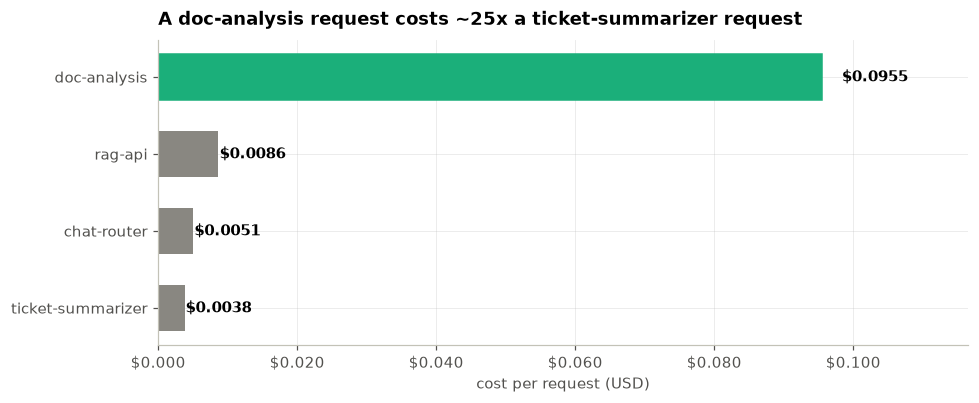

In [22]:
# Where does each dollar actually come from? Cost per request makes the
# per-unit economics explicit, which the share chart alone cannot show.
fig, ax = plt.subplots(figsize=(9.5, 3.6))
vals = svc["usd_per_request"].sort_values()
bars = ax.barh(np.arange(len(vals)), vals.values, color=C_MUTED, height=0.6)
bars[-1].set_color(C_COST)                       # emphasis: highlight the one that matters
ax.set_yticks(np.arange(len(vals)), vals.index, fontsize=9.5)
ax.set_xlabel("cost per request (USD)", fontsize=9.5)
ax.set_title("A doc-analysis request costs ~25x a ticket-summarizer request",
             loc="left", pad=10)
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("${x:.3f}"))
for i, v in enumerate(vals.values):
    ax.text(v * 1.03, i, f"${v:.4f}", va="center", fontsize=9.5, fontweight="bold")
ax.set_xlim(0, vals.max() * 1.22)
plt.show()

In [23]:
# Does the conclusion survive the cleaning choices? Re-rank on raw-ish data.
alt = raw.copy()
alt["service"] = (alt["service"].astype(str).str.strip().str.lower()
                  .str.replace(r"[\s_]+", "-", regex=True))
alt["cost_usd"] = pd.to_numeric(alt["cost_usd"], errors="coerce")
alt_rank = alt.groupby("service")["cost_usd"].sum().sort_values(ascending=False)

print("Cost ranking BEFORE cleaning (labels normalised only, so it is comparable):")
print((alt_rank / alt_rank.sum()).map("{:.1%}".format).to_string())
print("\nCost ranking AFTER cleaning:")
print(svc["cost_share"].map("{:.1%}".format).to_string())
print("\n  Same ranking, same leader. The cleaning changes the magnitude of doc-analysis's")
print("  share (the $106 billing anomaly inflated it) but not the conclusion — so the")
print("  answer is robust to the judgement calls in §3.")

Cost ranking BEFORE cleaning (labels normalised only, so it is comparable):
service
doc-analysis         54.1%
rag-api              21.4%
chat-router          20.1%
ticket-summarizer     4.5%

Cost ranking AFTER cleaning:
service
doc-analysis         52.3%
rag-api              22.3%
chat-router          20.7%
ticket-summarizer     4.7%

  Same ranking, same leader. The cleaning changes the magnitude of doc-analysis's
  share (the $106 billing anomaly inflated it) but not the conclusion — so the
  answer is robust to the judgement calls in §3.


### Answer to Q2

**`doc-analysis` is the biggest cost driver — 52% of total spend — and it is
*not* request volume. It is unit cost multiplied by verbosity.**

| | doc-analysis | vs the rest |
|---|---|---|
| Share of **requests** | 6.5% | the **lowest** of the four services |
| Share of **tokens** | 22% | second |
| Share of **cost** | **52%** | more than the other three combined |

Decomposed against the cheapest service, `ticket-summarizer`:

* **Request volume: ×0.45** — it makes *fewer* requests. Volume is pushing its cost
  *down*, not up.
* **Tokens per request: ×6.1** — 2,122 vs 347. It reads whole documents.
* **Price per 1k tokens: ×4.1** — \$0.045 vs \$0.011. It is the only service on
  `gpt-4.1` rather than `gpt-4.1-mini`.

Those two factors compound: **one doc-analysis request costs ~25× one
ticket-summarizer request.**

**So the lever is not "make fewer calls".** It is (a) the model choice and
(b) how much context each call carries. Concretely: routing even the easier
doc-analysis work to `gpt-4.1-mini` would cut its unit price by ~73%; trimming
context would attack the other factor. Cutting request volume — the intuitive
first move — would barely move the bill.

---
## 6. Q3 — Assumptions, exclusions and transformations

In [24]:
log = pd.DataFrame(DECISIONS)
print(f"{len(log)} documented transformations, affecting "
      f"{log['Rows'].sum()} of {len(raw)} raw rows "
      f"({log['Rows'].sum() / len(raw):.1%})\n")
display(log.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

8 documented transformations, affecting 8 of 298 raw rows (2.7%)



Issue,Rows,Action,Rationale,Impact
`team` case variant ('platform' vs 'Platform'),1,Normalised to Title Case,"Same team, two spellings; ungrouped it would split every per-team total.",team labels 4 -> 3
`service` label variant ('Chat Router' vs 'chat-router'),1,Normalised to lowercase-hyphenated,"Same service, two spellings; the cost-driver ranking depends on grouping it as one.",service labels 5 -> 4
`date` mixes ISO-8601 and DD/MM/YYYY,1,"Parsed ISO first, then day-first for the remainder","Day-first is forced by the data: month-first would fall outside the 1 Apr - 14 Jun window, and day-first fills the panel's only gap.",all 298 rows now datetime64[ns]
Exact duplicate row (2026-04-04 Platform / chat-router),1,"Dropped, keeping the first occurrence",Identical in all seven columns. A restatement would differ in at least one measure; identical rows are a double-counted export.,298 -> 297 rows; that day's chat-router cost halves to its true value
Missing `cost_usd` (2026-05-03 Support / ticket-summarizer),1,Imputed = total_tokens x median $/1k for that model,"Token count is present and pricing is deterministic per model, so the cost is recoverable rather than lost.",+$1.14 recovered
Missing `total_tokens` (2026-05-14 Platform / rag-api),1,Imputed = cost_usd / median $/1k for that model,"The inverse of the above; billing is present, so the token count is implied.","+601,661 tokens recovered"
Impossible `requests = -25` (2026-04-30 Research / doc-analysis),1,Imputed from the service's median tokens/request -> 176,"Tokens and cost on that row are internally consistent with the gpt-4.1 rate, so only the request count is corrupt. abs(-25) would imply 15,071 tokens/request, ~6x the service norm — so the magnitude is wrong too, not just the sign.",affects request-volume series only; cost and tokens untouched
Cost 4.8x the model's rate (2026-05-26 Research / doc-analysis),1,Restated at the model's published rate ($27.97),"Tokens/request on that row is normal for the service, so usage was ordinary and the billed amount is the outlier. Pricing is deterministic, so the correct figure is computable — better than capping at an arbitrary percentile.",removes $106.29 of anomalous spend (4.0% of the total)


In [25]:
recon = pd.DataFrame({
    "metric": ["rows", "total cost (USD)", "total requests", "total tokens"],
    "raw": [len(raw),
            pd.to_numeric(raw["cost_usd"], errors="coerce").sum(),
            pd.to_numeric(raw["requests"], errors="coerce").sum(),
            pd.to_numeric(raw["total_tokens"], errors="coerce").sum()],
    "clean": [len(df), df["cost_usd"].sum(), df["requests"].sum(), df["total_tokens"].sum()],
})
recon["delta"] = recon["clean"] - recon["raw"]
recon["delta %"] = recon["delta"] / recon["raw"] * 100
print("Raw -> clean reconciliation (every difference is explained by the log above):\n")
display(recon.style.hide(axis="index").format(
    {"raw": "{:,.2f}", "clean": "{:,.2f}", "delta": "{:+,.2f}", "delta %": "{:+.2f}%"}))

Raw -> clean reconciliation (every difference is explained by the log above):



metric,raw,clean,delta,delta %
rows,298.00,297.00,-1.00,-0.34%
total cost (USD),"2,742.40","2,632.20",-110.20,-4.02%
total requests,"223,930.00","223,095.00",-835.00,-0.37%
total tokens,"129,083,151.00","129,263,808.00","+180,657.00",+0.14%


### Assumptions

1. **Day-first for the one non-ISO date.** `09/05/2026` → 9 May 2026. Month-first
   would put it in September, outside the dataset's window, and day-first fills
   the panel's only service gap. *If wrong:* one row moves by four months; totals
   are unaffected.
2. **Pricing is deterministic per model.** Effective unit cost clusters within
   ±0.5% of \$0.012/1k (`gpt-4.1-mini`) and \$0.045/1k (`gpt-4.1`), so both
   imputations and the billing-anomaly restatement rest on a rate the data itself
   establishes. *If wrong:* two imputed cells and one restated cost are
   approximate — together **1.0%** of total spend.
3. **Identical rows are double-counted exports, not restatements.** A genuine
   restatement would differ in at least one measure. *If wrong:* one day of
   chat-router is understated by ~\$5.
4. **`cost_usd` is USD, tax-exclusive, and comparable across the window.** No
   currency or list-price column is provided, and no discontinuity appears in the
   unit-cost series to suggest a repricing mid-window.
5. **A row is a complete daily total** for its team/service/model, not a sample.
6. **`total_tokens` is prompt + completion combined.** The workbook provides no
   split, so the prompt/completion mix cannot be analysed — noted in §7.

### Exclusions

* **Nothing was dropped from the analysis** other than the one exact duplicate.
  Both rows with impossible values were *repaired* rather than removed, because
  each had enough intact fields to reconstruct the broken one.
* **Three service-days are genuinely absent** from the source (300 expected panel
  cells, 297 present). These are treated as *not recorded*, not as zero usage —
  filling them with zeros would bias the daily means downward and dent the trend.

### Transformations

Label canonicalisation → date parsing → numeric coercion → de-duplication →
imputation → repair of impossible values → derived fields. The order is
load-bearing: labels before de-duplication (or `Chat Router` and `chat-router`
never collide), de-duplication before imputation (or a duplicated row skews the
rates used to impute).

### Findings worth escalating

* **A 4.8× billing anomaly on 2026-05-26** — \$134.26 charged where the published
  rate gives \$27.97, a **\$106 overcharge on a single line**, ~4% of the
  window's total spend. Restated here, but this warrants a query to the vendor.
* **Data-quality defects in 8 of 298 rows (2.7%)** across seven distinct classes.
  At this rate, unvalidated ingestion would corrupt roughly one line in thirty-seven.
  §7 proposes the fix.

---
## 7. What I would do next

**On the cost finding.** Route triage: not every document needs `gpt-4.1`. Sending
the routine share of `doc-analysis` to `gpt-4.1-mini` attacks the ×4.1 price
factor directly; context trimming attacks the ×6.1 verbosity factor. Together
they address ~52% of the bill. Cutting request volume — the intuitive first move
— attacks the one factor that is already working in our favour.

**On the data quality.** Every defect found here is machine-detectable at
ingestion:

| Check | Catches |
|---|---|
| `date` matches ISO-8601 | the mixed-format row |
| `team`/`service` in a controlled vocabulary | both label variants |
| `requests`, `tokens`, `cost` all `> 0` | the negative request count |
| `cost ÷ tokens` within ±10% of the model's rate | the 4.8× billing anomaly |
| unique on (date, team, service, model) | the duplicated export |
| non-null on all measures | both missing cells |

Six assertions would have caught all seven issues at load time instead of in
analysis. **That is the same argument Part 2 makes about trade capture**: validate
at the boundary, reject loudly, and keep an audit trail of every decision — which
is exactly what the `DECISIONS` log in this notebook is a manual version of.

**On the analysis.** With a prompt/completion token split, the verbosity factor
could be attributed to input context versus output length — which decides whether
the fix is prompt engineering or output caps. That column is not in this dataset.